<a href="https://colab.research.google.com/github/Soheilp86/Statistical-Machine-Learning/blob/main/12-MLR_Performance_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Performance Metrics for Multiple Linear Regression

**Objective**: Understand how to evaluate and compare multiple linear regression models using different performance metrics.

## 1. Setup: Libraries and Data

Let's start by importing our tools and creating a meaningful synthetic dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Synthetic Dataset: House Price Prediction

We'll predict house prices based on:
- Square footage
- Number of bedrooms
- Age of the house

This is a realistic scenario where we expect these features to have a linear relationship with price.

In [3]:
# Generate synthetic data
n_samples = 100

# Features
square_footage = np.random.uniform(800, 4000, n_samples)  # sq ft
bedrooms = np.random.randint(1, 6, n_samples)              # number of bedrooms
age = np.random.uniform(0, 50, n_samples)                  # years old

# True relationship (with some noise)
# Price = 150 * sqft + 50000 * bedrooms - 500 * age + noise
price = (150 * square_footage +
         50000 * bedrooms -
         500 * age +
         np.random.normal(0, 20000, n_samples))  # Add realistic noise

# Create DataFrame
data = pd.DataFrame({
    'square_footage': square_footage,
    'bedrooms': bedrooms,
    'age': age,
    'price': price
})

print("Dataset Preview:")
print(data.head())
print(f"\nShape: {data.shape}")
print(f"\nBasic Statistics:")
print(data.describe())

Dataset Preview:
   square_footage  bedrooms        age          price
0     1066.510116         5  43.715880  407868.437366
1     1093.453271         1  25.761803  216421.177073
2     2727.810963         1  48.655517  435102.916460
3     2571.849768         2  30.096770  453215.105404
4     1480.729264         1  11.192453  262553.903590

Shape: (100, 4)

Basic Statistics:
       square_footage    bedrooms         age          price
count      100.000000  100.000000  100.000000     100.000000
mean      2431.546034    2.860000   25.169796  496797.070788
std        939.681483    1.463495   14.608149  152075.478460
min        903.411044    1.000000    0.129751  192511.616423
25%       1611.229352    2.000000   12.114700  374480.005761
50%       2335.011006    3.000000   26.527644  506064.669444
75%       3199.863859    4.000000   36.848408  623220.056353
max       3986.979974    5.000000   49.862777  814850.153231


---
## 2. Quick Reminder: RMSE and MSE

Before we dive into new metrics, let's quickly recall two metrics you already know:

### **Mean Squared Error (MSE = $(1/n) \sum (y_i -\hat y_i)^2$)**

Average of squared differences between predicted and actual values.
We use square root to get rid of the negative sign. So taking the average penalizes large errors heavily. But its hard to interpret directly as it does not have the same unit as y.


### **Root Mean Squared Error (RMSE = $\sqrt{\text{MSE}}$)**
Average prediction error" in the same units as y (e.g., dollars if y is price. Easier to interpret and communicate

These metrics measure **prediction accuracy**: how off your model's prediction is on average. But don't account for **model complexity** (how many variables we use for prediction) or how much **variance the model explains**.

In [4]:
# Fit the model using sklearn
X = data[['square_footage', 'bedrooms', 'age']]
y = data['price']

model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate MSE and RMSE
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print("=" * 60)
print("PREDICTION ERROR METRICS (Reminder)")
print("=" * 60)
print(f"MSE:  ${mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print("\nInterpretation:")
print(f"On average, our predictions are off by about ${rmse:,.0f}")

PREDICTION ERROR METRICS (Reminder)
MSE:  $429,475,151.78
RMSE: $20,723.78
MAE:  $16,652.51

Interpretation:
On average, our predictions are off by about $20,724


---
## 3. Coefficient of Determination

### **$R^2$**

This tells us how much of the variation in the target variable our model can explain compared with a simple baseline.

A simple baseline is to always predict the average (what we would use to guess for prediction):


**$$SS_{\text{average}} = \sum (y_i -y_{\text{average}})^2$$**


Your model makes its own predictions and the error is


**$$SS_{\text{res}} = \sum (y_i -y_{\text{predicted}})^2$$**

$R^2$ is defined as

$$R^2 = 1- \frac{SS_{\text{res}}}{SS_{\text{average}}}$$

In simple terms, it tells us how much better our model is than simply guessing the average. In otherwords **how much of the variation in a target variable can be predicted or explained by your predictors**.


- $R^2$ = 0 --> Model explains 0% of the variance (basically useless)
- $R^2$ = 0.5 --> Model explains 50% of the variance (baseline! We could achiev this by guessing)
- $R^2$ = 1.0 --> Model explains 100% of the variance (perfect fit, unrealistic)


For example, if house prices range from $300,000 to $5,000,000, $R^2$ tells us how much of that variation can be explained by features such as square footage, lot size, and number of bedrooms.

**Problem**: $R^2$ usually increases when we add more predictors, even if they are not useful. This can lead to overfitting.

The fix is to use


### **Adjusted R^2**

Adjusted $R^2$ adds a penalty for adding predictors. It only rewards a new predictor if it improves the model enough to justify the added complexity. It can actually decrease when you add a useless predictor.



The formula adjusts the standard components by factoring in the sample size ($n$) and the number of independent variables ($k$):

$$R_{\text{adj}}^{2} = 1 - \left( \frac{(1 - R^{2})(n - 1)}{n - k - 1} \right)$$


where n is the sample size and k is the number of predictors.


**Use Adjusted $R^2$ when comparing models with different numbers of predictors.**

In [5]:
# Calculate R² using sklearn
r2 = r2_score(y, y_pred)

# Calculate Adjusted R² manually
n = len(y)
k = X.shape[1]  # number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("=" * 60)
print("VARIANCE EXPLAINED METRICS")
print("=" * 60)
print(f"R²:          {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")
print(f"\nInterpretation:")
print(f"- Our model explains {r2*100:.1f}% of the variance in house prices")
print(f"- After accounting for complexity (3 predictors), it's {adj_r2*100:.1f}%")
print(f"\nNote: Adjusted R² < R² (as expected due to penalty)")

VARIANCE EXPLAINED METRICS
R²:          0.9812
Adjusted R²: 0.9807

Interpretation:
- Our model explains 98.1% of the variance in house prices
- After accounting for complexity (3 predictors), it's 98.1%

Note: Adjusted R² < R² (as expected due to penalty)


### Visual: What R² Means

Let's visualize the relationship between actual and predicted prices.

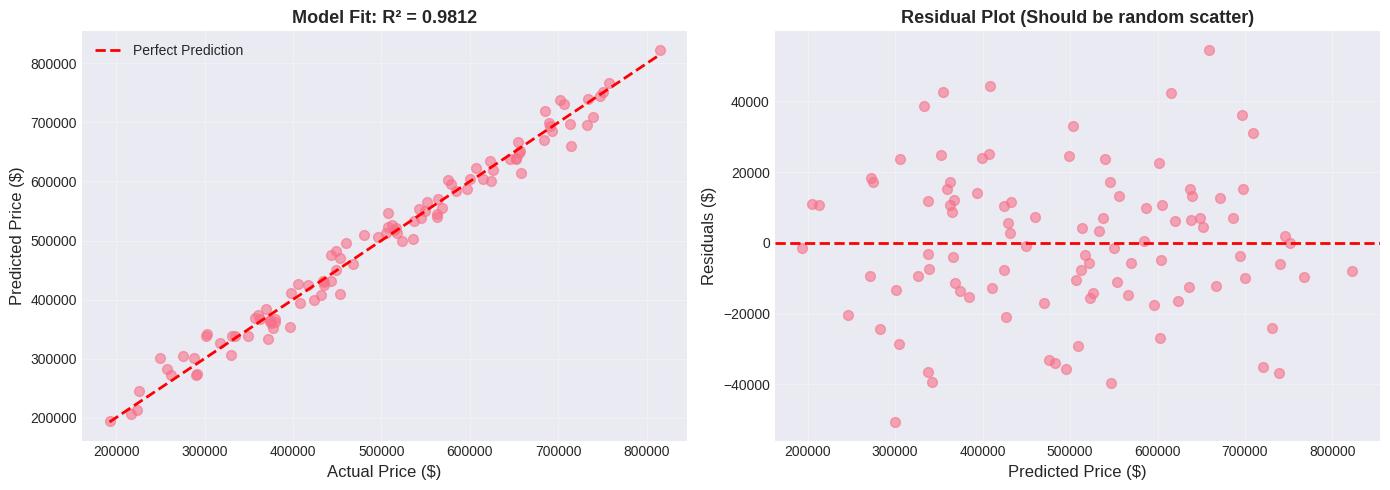


What we're looking for:
- Left plot: Points close to red line = good R²
- Right plot: Residuals randomly scattered around 0 = good assumptions


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y, y_pred, alpha=0.6, s=50)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'Model Fit: R² = {r2:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Residuals
residuals = y - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Residual Plot (Should be random scatter)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWhat we're looking for:")
print("- Left plot: Points close to red line = good R²")
print("- Right plot: Residuals randomly scattered around 0 = good assumptions")

---
## 4. F-Statistic: Is the Model Useful?

### **What is the F-Statistic?**

**Question it answers**: "Is the overall model statistically significant? Does it explain variance better than just predicting the mean?"

**Intuition**:
- Compares how well the model explains variance vs. how much unexplained variance remains
- Larger F-statistic → Model is better than baseline → More likely significant
- Comes with a **p-value** (probability that this is just by chance)

**Rule of Thumb**:
- If **p-value < 0.05**: Model is statistically significant ✓ (reject null hypothesis: "model is useless")
- If **p-value ≥ 0.05**: Model might not be useful (fail to reject null hypothesis)

**Why it matters**:
- Even a model with high R² can be meaningless if it's based on random data
- F-statistic + p-value tell us if improvements are real or just luck

In [ ]:
# Use statsmodels for detailed regression output
X_with_const = sm.add_constant(X)  # Add intercept
sm_model = sm.OLS(y, X_with_const).fit()

# Print summary (this is the standard output in statistics)
print(sm_model.summary())

### How to Read the Statsmodels Summary (Intuitive Guide)

The summary table looks overwhelming at first, but here's what students should focus on:

**Top section (right side)**:
- **R-squared**: The R² value we care about
- **Adj. R-squared**: The adjusted R² value (penalizes for adding predictors)
- **F-statistic** and **Prob (F-statistic)**: These answer "Is the model statistically significant?" If the Prob is < 0.05, our model is doing something meaningful, not just random noise.

**Middle section (the coefficient table)**:
- **coef**: The coefficient (slope) for each predictor. For example, square_footage has coef ≈ 150, meaning each additional square foot increases price by ~$150.
- **P>|t|**: The p-value for each predictor. If < 0.05, that predictor is statistically significant (meaningful).
- **[0.025, 0.975]**: The 95% confidence interval. If it includes 0, the predictor might not be significant.

For now, focus on the top section: **R², Adjusted R², and F-statistic p-value** tell you if your model is good and significant.

In [ ]:
# Extract F-statistic and p-value
f_stat = sm_model.fvalue
f_pval = sm_model.f_pvalue

print("=" * 60)
print("OVERALL MODEL SIGNIFICANCE (F-Statistic)")
print("=" * 60)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value:     {f_pval:.2e}")
print()
if f_pval < 0.05:
    print("✓ Model is STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("  → The predictors collectively explain variance better than baseline")
else:
    print("✗ Model is NOT statistically significant (p ≥ 0.05)")
    print("  → Predictors don't meaningfully improve over baseline")

---
## 5. Summary: How to Choose and Interpret Metrics

### **Quick Reference Guide**

| Metric | What It Measures | When to Use | Interpretation |
|--------|------------------|-------------|----------------|
| **RMSE** | Prediction error (units of y) | Always | "Average error of ${RMSE:.0f}" |
| **MSE** | Squared prediction error | Less common (hard to interpret) | Compare models only |
| **R²** | % of variance explained | Always | "Model explains X% of variance" |
| **Adjusted R²** | R² with penalty for complexity | Compare models | "Fair comparison across #predictors" |
| **F-statistic** | Overall model significance | Always | p < 0.05 = statistically significant |

### **Typical Workflow**

1. **Fit your model** → Get predictions
2. **Check RMSE & R²** → "How well does it fit?"
3. **Check F-statistic** → "Is it significant?"
4. **Compare models with Adjusted R²** → "Which is better?"

### **Red Flags**

- High R² but low F-statistic p-value → Something's wrong
- Adjusted R² much lower than R² → Too many predictors

In [ ]:
# Final Summary Table
print("\n" + "=" * 70)
print("COMPREHENSIVE MODEL EVALUATION SUMMARY")
print("=" * 70)
print()
print("Our Multiple Linear Regression Model:")
print(f"  Price ~ Square Footage + Bedrooms + Age")
print()
print("Metrics Summary:")
print("-" * 70)
print(f"RMSE:              ${rmse:>10,.0f}  (prediction error in dollars)")
print(f"R²:                {r2:>10.4f}  (explains {r2*100:.1f}% of variance)")
print(f"Adjusted R²:       {adj_r2:>10.4f}  (fair comparison metric)")
print(f"F-statistic:       {f_stat:>10.4f}  (p-value: {f_pval:.2e})")
print("-" * 70)
print()
print("Conclusions:")
print("✓ Model fits well (R² = {:.4f})".format(r2))
print("✓ Model is statistically significant (F-test p < 0.001)")
print("✓ Ready for prediction and inference!")
print("=" * 70)

---

## Next Step: Practice

In the group practice session, you'll:
1. **Fit models** with different predictors
2. **Calculate all metrics** we learned today (RMSE, R², Adjusted R², F-statistic)
3. **Compare models** using R² and Adjusted R²
4. **Make decisions** about which model to use and why

You'll see how these metrics guide real-world model selection and help avoid overfitting!